# TataVision — XCI-Style Coloured Sketch Renderer

This notebook creates both the coloured hand-drawn output shown in the XCI-Sketch paper and a more realistic painted output that preserves the reference photograph's original colours. It is designed as TataVision's **final composition stage**.

Best pipeline: **reference photograph + curve-module output + optional shading output → coloured sketch**. If no curve image is supplied, an automatic OpenCV contour fallback is used. That fallback is not an AI model; the AI components remain the upstream curve and shading models.


## 1. Install and import dependencies


In [1]:
%pip install -q opencv-python-headless matplotlib pillow scikit-learn scikit-image


Note: you may need to restart the kernel to use updated packages.


In [12]:
from pathlib import Path
import json
import shutil
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.cluster import MiniBatchKMeans
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

print('Imports complete.')


Imports complete.


## 2. Configure inputs
`REFERENCE_IMAGE` is required. `CURVE_IMAGE` should be the black-on-white output of TataVision's curve module. `SHADING_IMAGE` can be the fused or quantized result from the Depth Anything shading notebook. Set optional paths to `None` when unavailable.


Reference: /home/ridhurshan/Desktop/new ai/e/input.jpg
Resolution: (1080, 1247)


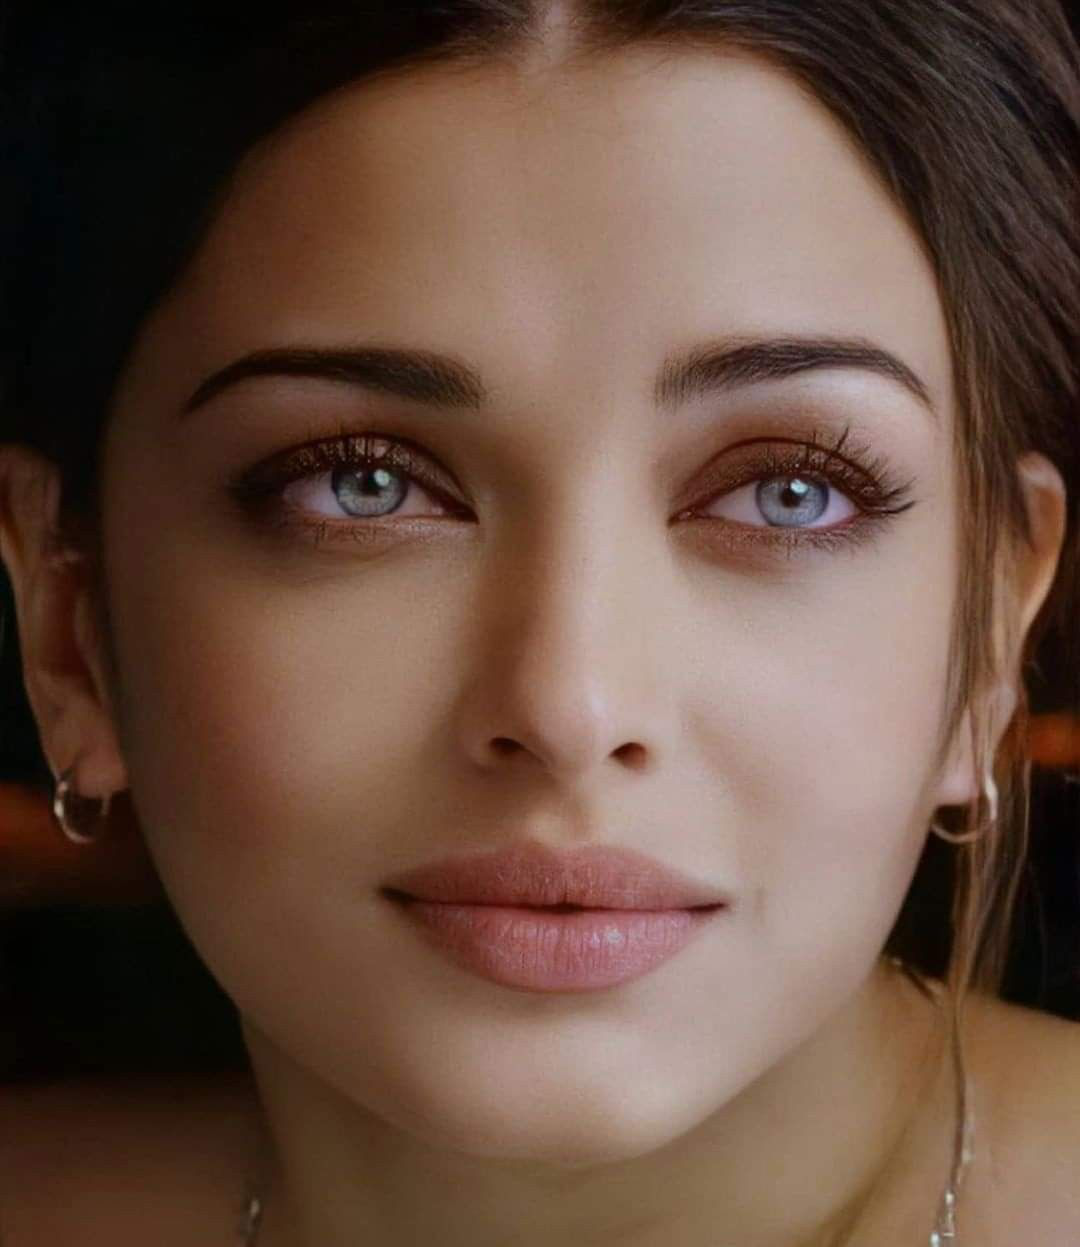

In [13]:
USE_COLAB_UPLOAD = False
REFERENCE_IMAGE = 'input.jpg'
CURVE_IMAGE = None  # Example: 'tatavision_curve_output.png'
SHADING_IMAGE = None  # Example: 'tatavision_shading_output/03_fused_shading.png'

if USE_COLAB_UPLOAD:
    try:
        from google.colab import files
        print('Upload the original colour reference image.')
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError('No image was uploaded.')
        REFERENCE_IMAGE = next(iter(uploaded))
    except ImportError as exc:
        raise RuntimeError('Colab upload was requested, but this is not Google Colab.') from exc

reference_path = Path(REFERENCE_IMAGE)
if not reference_path.exists():
    raise FileNotFoundError(f'Reference image not found: {reference_path.resolve()}')

reference_pil = Image.open(reference_path).convert('RGB')
reference_rgb = np.asarray(reference_pil, dtype=np.uint8)
height, width = reference_rgb.shape[:2]
print('Reference:', reference_path.resolve())
print('Resolution:', (width, height))
display(reference_pil)


## 3. Prepare the sketch contour
The external curve-module output is preferred because it represents TataVision's trained curve component. The fallback combines edge-preserving smoothing, adaptive thresholding and Canny edges.


Contour source: automatic OpenCV fallback


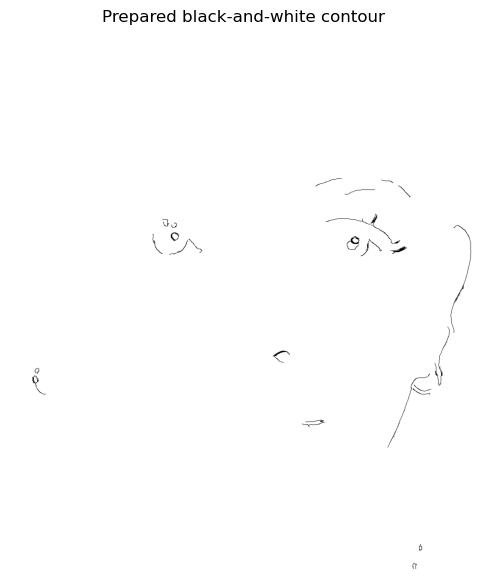

In [14]:
LINE_THICKNESS = 1  # Recommended: 1 or 2
REMOVE_SMALL_COMPONENTS = 12

def remove_small_components(mask, minimum_area=12):
    count, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), 8)
    cleaned = np.zeros_like(mask, dtype=np.uint8)
    for label in range(1, count):
        if stats[label, cv2.CC_STAT_AREA] >= minimum_area:
            cleaned[labels == label] = 1
    return cleaned.astype(bool)

def automatic_contours(rgb):
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    smooth = cv2.bilateralFilter(gray, 9, 55, 55)
    adaptive = cv2.adaptiveThreshold(
        smooth, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 9, 7
    )
    canny = cv2.Canny(smooth, 55, 135)
    line_mask = (adaptive < 128) | (canny > 0)
    return remove_small_components(line_mask, REMOVE_SMALL_COMPONENTS)

def load_external_contours(path, output_size):
    curve = Image.open(path).convert('L').resize(output_size, Image.Resampling.LANCZOS)
    curve_gray = np.asarray(curve, dtype=np.uint8)
    # Otsu handles different white-background line drawings better than a fixed threshold.
    _, binary = cv2.threshold(curve_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary == 0

curve_source = 'automatic OpenCV fallback'
if CURVE_IMAGE and Path(CURVE_IMAGE).exists():
    line_mask = load_external_contours(CURVE_IMAGE, (width, height))
    curve_source = str(Path(CURVE_IMAGE))
else:
    line_mask = automatic_contours(reference_rgb)

if LINE_THICKNESS > 1:
    kernel = np.ones((LINE_THICKNESS, LINE_THICKNESS), np.uint8)
    line_mask = cv2.dilate(line_mask.astype(np.uint8), kernel, iterations=1).astype(bool)

line_art = np.full((height, width), 255, dtype=np.uint8)
line_art[line_mask] = 0
print('Contour source:', curve_source)
plt.figure(figsize=(9, 7))
plt.imshow(line_art, cmap='gray', vmin=0, vmax=255)
plt.title('Prepared black-and-white contour')
plt.axis('off')
plt.show()


## 4. Simplify colours using the XCI principle
The paper applies repeated Gaussian blur followed by K-means quantization. This implementation clusters in Lab space, which is more defensible for perceptual colour similarity.


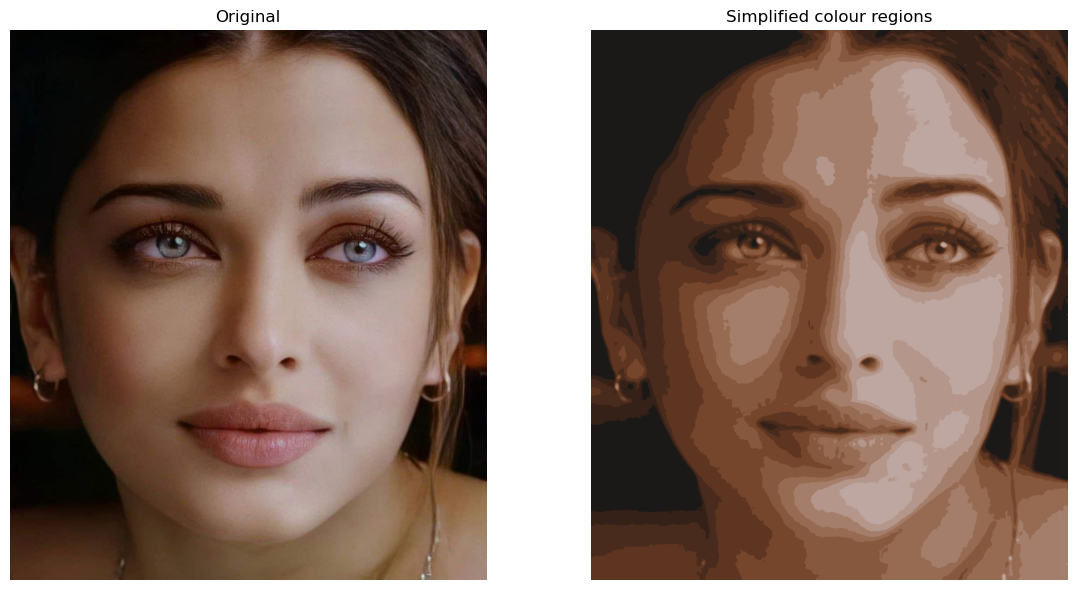

In [15]:
PALETTE_SIZE = 10
GAUSSIAN_ITERATIONS = 3
SATURATION_FACTOR = 1.35  # Paper used 1.8; 1.35 usually avoids clipping
PAPER_WHITENING = 0.08
RANDOM_STATE = 42

smoothed = reference_rgb.copy()
for _ in range(GAUSSIAN_ITERATIONS):
    smoothed = cv2.GaussianBlur(smoothed, (5, 5), 0)
smoothed = cv2.bilateralFilter(smoothed, 9, 45, 45)

lab = cv2.cvtColor(smoothed, cv2.COLOR_RGB2LAB)
pixels = lab.reshape(-1, 3).astype(np.float32)
kmeans = MiniBatchKMeans(
    n_clusters=PALETTE_SIZE, random_state=RANDOM_STATE, batch_size=4096, n_init=5
)
labels = kmeans.fit_predict(pixels).reshape(height, width)
centres_lab = np.clip(kmeans.cluster_centers_, 0, 255).astype(np.uint8)
quantized_lab = centres_lab[labels]
quantized_rgb = cv2.cvtColor(quantized_lab, cv2.COLOR_LAB2RGB)

# Controlled saturation enhancement.
hsv = cv2.cvtColor(quantized_rgb, cv2.COLOR_RGB2HSV).astype(np.float32)
hsv[:, :, 1] = np.clip(hsv[:, :, 1] * SATURATION_FACTOR, 0, 255)
quantized_rgb = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
quantized_rgb = np.clip(
    quantized_rgb.astype(np.float32) * (1.0 - PAPER_WHITENING) + 255.0 * PAPER_WHITENING,
    0, 255
).astype(np.uint8)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(reference_rgb); plt.title('Original'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(quantized_rgb); plt.title('Simplified colour regions'); plt.axis('off')
plt.tight_layout(); plt.show()


## 5. Optionally retain the shading module's luminance
This keeps TataVision's modular sequence intact: the colour stage adds chrominance without discarding the shading stage.


In [16]:
SHADING_STRENGTH = 0.55
colour_base = quantized_rgb.copy()
shading_used = False

if SHADING_IMAGE and Path(SHADING_IMAGE).exists():
    shading = Image.open(SHADING_IMAGE).convert('L').resize((width, height), Image.Resampling.LANCZOS)
    shading_l = np.asarray(shading, dtype=np.float32)
    base_lab = cv2.cvtColor(colour_base, cv2.COLOR_RGB2LAB).astype(np.float32)
    base_lab[:, :, 0] = (1.0 - SHADING_STRENGTH) * base_lab[:, :, 0] + SHADING_STRENGTH * shading_l
    colour_base = cv2.cvtColor(np.clip(base_lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2RGB)
    shading_used = True
    print('Applied shading:', Path(SHADING_IMAGE))
else:
    print('No external shading applied; the reference luminance is retained.')


No external shading applied; the reference luminance is retained.


## 6. Create coloured outline and final filled sketch


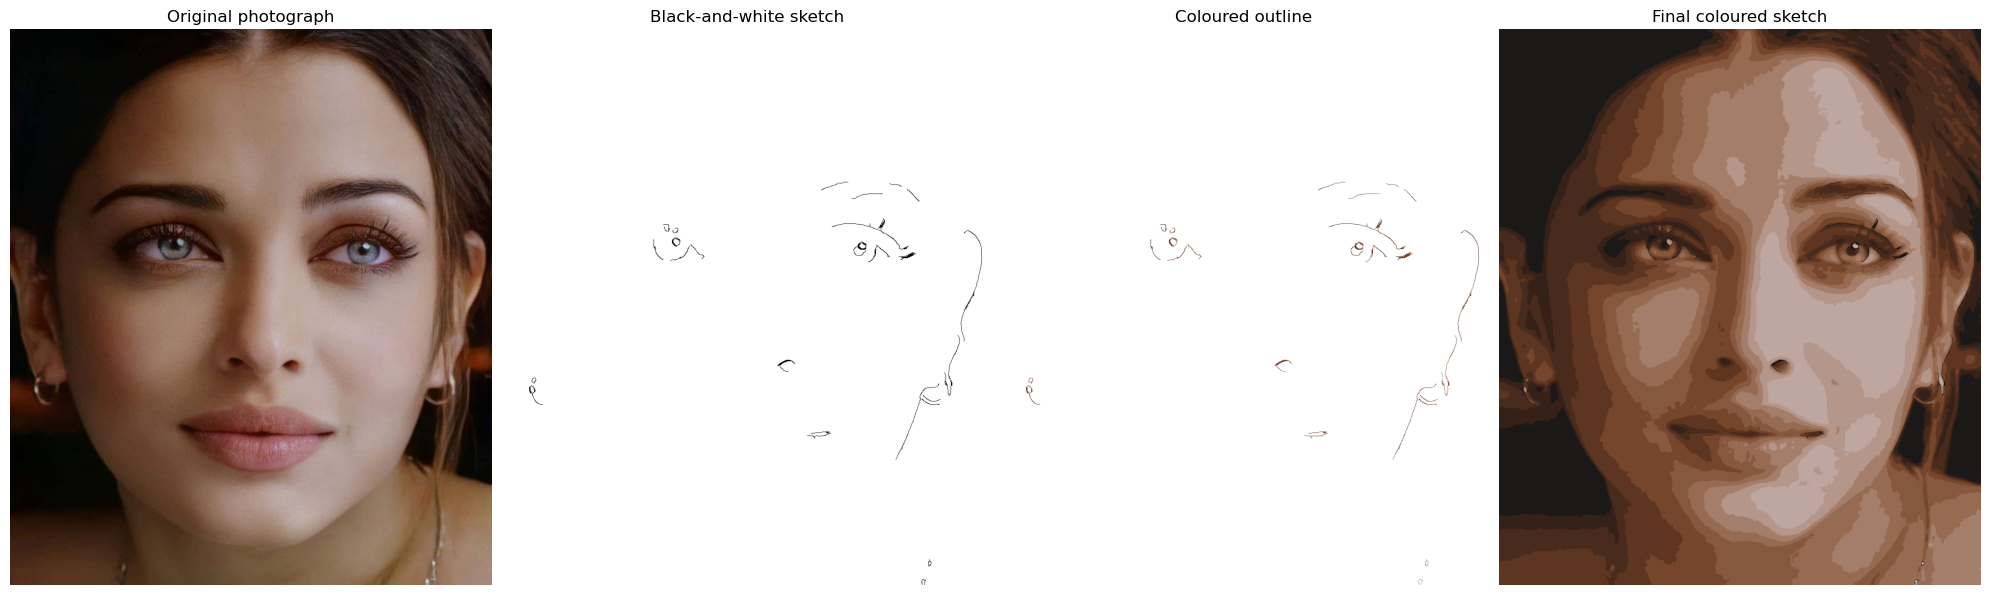

In [17]:
# Coloured-outline version: only contour pixels receive reference-derived colours.
coloured_outline = np.full_like(reference_rgb, 255)
coloured_outline[line_mask] = colour_base[line_mask]

# Final XCI-style filled sketch: simplified colour regions plus black contour.
final_sketch = colour_base.copy()
final_sketch[line_mask] = np.array([18, 18, 18], dtype=np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
items = [
    (reference_rgb, 'Original photograph'),
    (line_art, 'Black-and-white sketch'),
    (coloured_outline, 'Coloured outline'),
    (final_sketch, 'Final coloured sketch'),
]
for axis, (image, title) in zip(axes, items):
    axis.imshow(image, cmap='gray' if image.ndim == 2 else None)
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout(); plt.show()


## 7. Create a realistic painted result with original colours
This second output avoids strong posterization. It performs edge-aware painterly smoothing, restores the original Lab chroma, optionally retains TataVision shading, applies soft local-colour contours and adds subtle canvas grain.


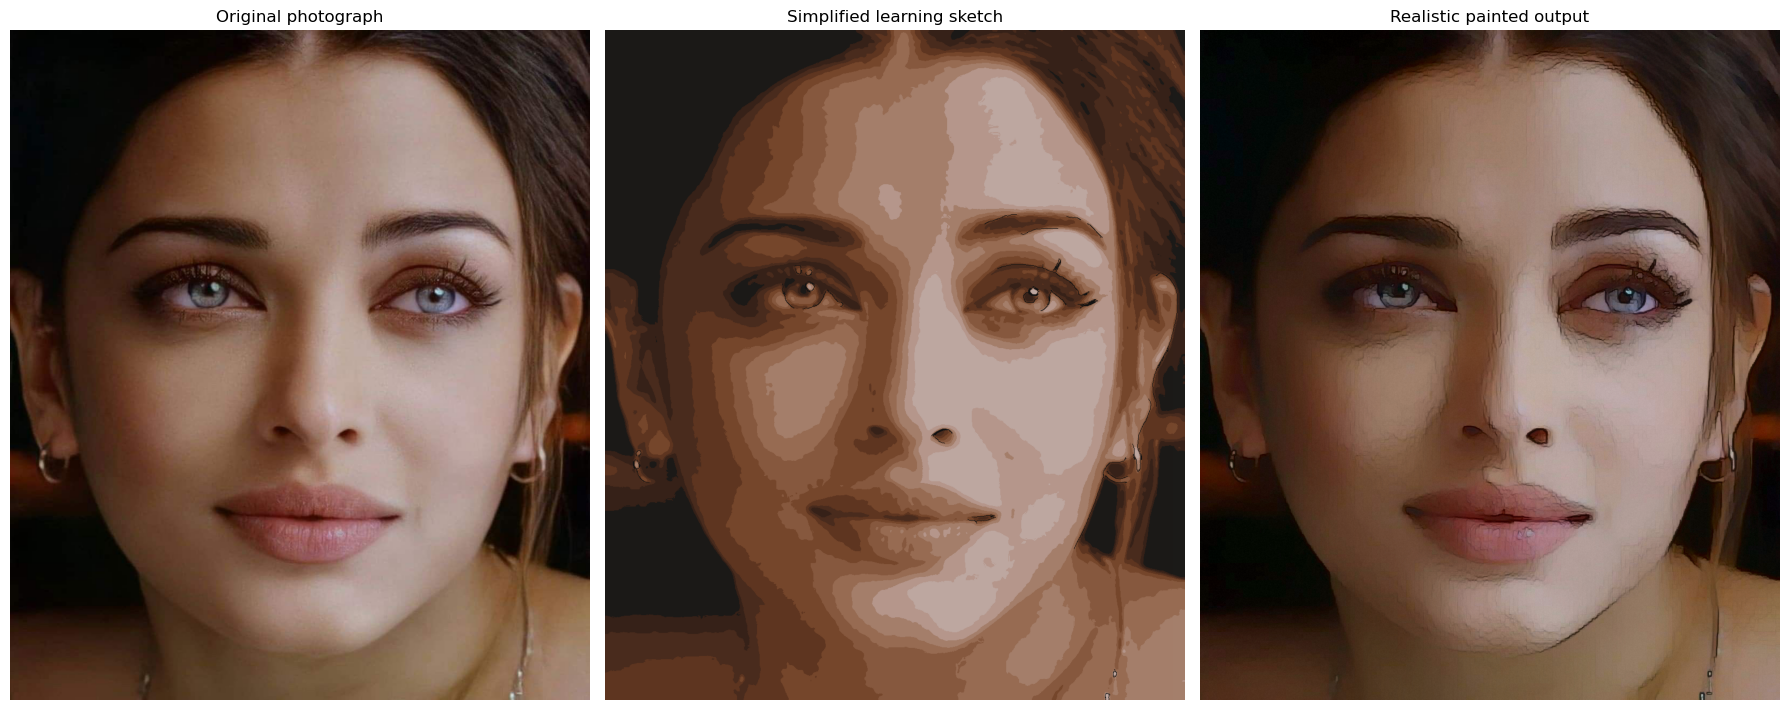

In [18]:
PAINT_SIGMA_SPATIAL = 75
PAINT_SIGMA_RANGE = 0.32
ORIGINAL_DETAIL_BLEND = 0.30
ORIGINAL_CHROMA_RETENTION = 0.88
SOFT_OUTLINE_OPACITY = 0.48
CANVAS_GRAIN_STRENGTH = 2.2

# Edge-aware stylization creates broad brush-like regions while retaining object boundaries.
reference_bgr = cv2.cvtColor(reference_rgb, cv2.COLOR_RGB2BGR)
painted_bgr = cv2.stylization(
    reference_bgr, sigma_s=PAINT_SIGMA_SPATIAL, sigma_r=PAINT_SIGMA_RANGE
)
painted_rgb = cv2.cvtColor(painted_bgr, cv2.COLOR_BGR2RGB)
painted_rgb = cv2.addWeighted(
    painted_rgb, 1.0 - ORIGINAL_DETAIL_BLEND, reference_rgb, ORIGINAL_DETAIL_BLEND, 0
)

# Restore the reference photograph's original chroma instead of inventing colours.
original_lab = cv2.cvtColor(reference_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
painted_lab = cv2.cvtColor(painted_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
painted_lab[:, :, 1:] = (
    (1.0 - ORIGINAL_CHROMA_RETENTION) * painted_lab[:, :, 1:]
    + ORIGINAL_CHROMA_RETENTION * original_lab[:, :, 1:]
)
if shading_used:
    painted_lab[:, :, 0] = (
        (1.0 - SHADING_STRENGTH) * painted_lab[:, :, 0] + SHADING_STRENGTH * shading_l
    )
painted_rgb = cv2.cvtColor(np.clip(painted_lab, 0, 255).astype(np.uint8), cv2.COLOR_LAB2RGB)

# Use soft darkened local colours rather than harsh pure-black cartoon lines.
soft_line_alpha = cv2.GaussianBlur(line_mask.astype(np.float32), (0, 0), 0.85)
soft_line_alpha = np.clip(soft_line_alpha * SOFT_OUTLINE_OPACITY, 0.0, 0.78)[:, :, None]
local_outline_colour = np.clip(painted_rgb.astype(np.float32) * 0.24, 8, 72)
realistic_painted = (
    painted_rgb.astype(np.float32) * (1.0 - soft_line_alpha)
    + local_outline_colour * soft_line_alpha
)

# Low-amplitude monochrome grain suggests canvas without changing object colours.
rng = np.random.default_rng(RANDOM_STATE)
grain = rng.normal(0.0, CANVAS_GRAIN_STRENGTH, (height, width, 1))
grain = cv2.GaussianBlur(grain.astype(np.float32), (0, 0), 0.45)
if grain.ndim == 2:
    grain = grain[:, :, None]
realistic_painted = np.clip(realistic_painted + grain, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for axis, image, title in zip(
    axes,
    [reference_rgb, final_sketch, realistic_painted],
    ['Original photograph', 'Simplified learning sketch', 'Realistic painted output'],
):
    axis.imshow(image)
    axis.set_title(title)
    axis.axis('off')
plt.tight_layout(); plt.show()


## 8. Generate progressive colouring stages
Dominant colour regions are introduced first while the black contour remains visible.


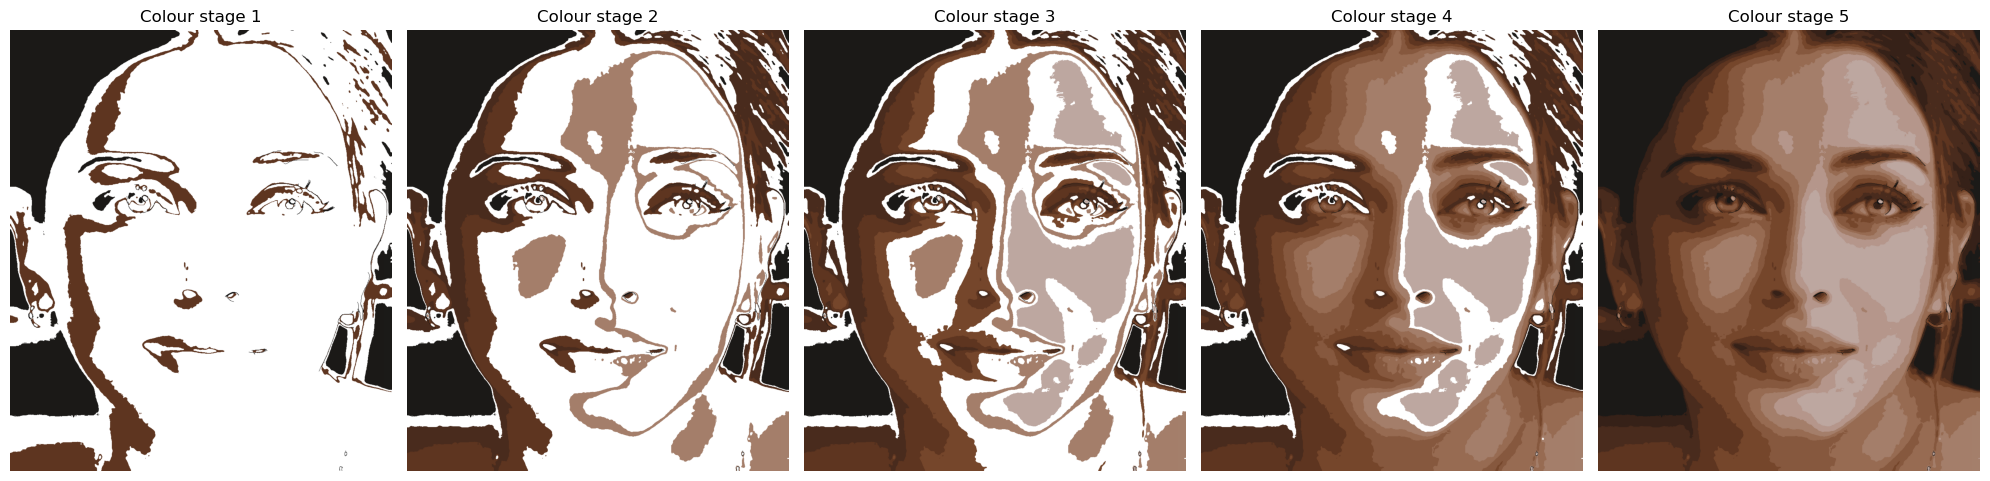

In [19]:
NUMBER_OF_STAGES = 5
cluster_counts = np.bincount(labels.ravel(), minlength=PALETTE_SIZE)
cluster_order = np.argsort(cluster_counts)[::-1]
groups = np.array_split(cluster_order, NUMBER_OF_STAGES)

progressive_stages = []
revealed = np.zeros((height, width), dtype=bool)
for group in groups:
    for cluster_id in group:
        revealed |= labels == cluster_id
    stage = np.full_like(reference_rgb, 255)
    stage[revealed] = colour_base[revealed]
    stage[line_mask] = np.array([18, 18, 18], dtype=np.uint8)
    progressive_stages.append(stage)

fig, axes = plt.subplots(1, NUMBER_OF_STAGES, figsize=(20, 5))
for index, (axis, stage) in enumerate(zip(axes, progressive_stages), start=1):
    axis.imshow(stage)
    axis.set_title(f'Colour stage {index}')
    axis.axis('off')
plt.tight_layout(); plt.show()


## 9. Calculate content-retention diagnostics
These are diagnostics, not proof of artistic quality. A stylized output is expected to differ from the photograph. Human evaluation should assess sketch resemblance, content retention and colour retention, matching the XCI-Sketch paper's evaluation logic.


In [20]:
reference_float = reference_rgb.astype(np.float32) / 255.0
final_float = final_sketch.astype(np.float32) / 255.0
painted_float = realistic_painted.astype(np.float32) / 255.0
metrics = {
    'MAE_to_reference': float(np.mean(np.abs(reference_float - final_float))),
    'MSE_to_reference': float(np.mean((reference_float - final_float) ** 2)),
    'PSNR_dB_to_reference': float(peak_signal_noise_ratio(reference_float, final_float, data_range=1.0)),
    'SSIM_to_reference': float(structural_similarity(
        reference_float, final_float, channel_axis=2, data_range=1.0
    )),
    'line_pixel_percentage': float(100.0 * np.mean(line_mask)),
    'painted_MAE_to_reference': float(np.mean(np.abs(reference_float - painted_float))),
    'painted_PSNR_dB_to_reference': float(peak_signal_noise_ratio(reference_float, painted_float, data_range=1.0)),
    'painted_SSIM_to_reference': float(structural_similarity(
        reference_float, painted_float, channel_axis=2, data_range=1.0
    )),
}
print(json.dumps(metrics, indent=2))


{
  "MAE_to_reference": 0.03906231001019478,
  "MSE_to_reference": 0.0024687566328793764,
  "PSNR_dB_to_reference": 26.075218413189056,
  "SSIM_to_reference": 0.7647314667701721,
  "line_pixel_percentage": 0.22260833407585615,
  "painted_MAE_to_reference": 0.022419780492782593,
  "painted_PSNR_dB_to_reference": 27.80052314180503,
  "painted_SSIM_to_reference": 0.8430691361427307
}


## 10. Export individual images, report, ZIP and comparison figures


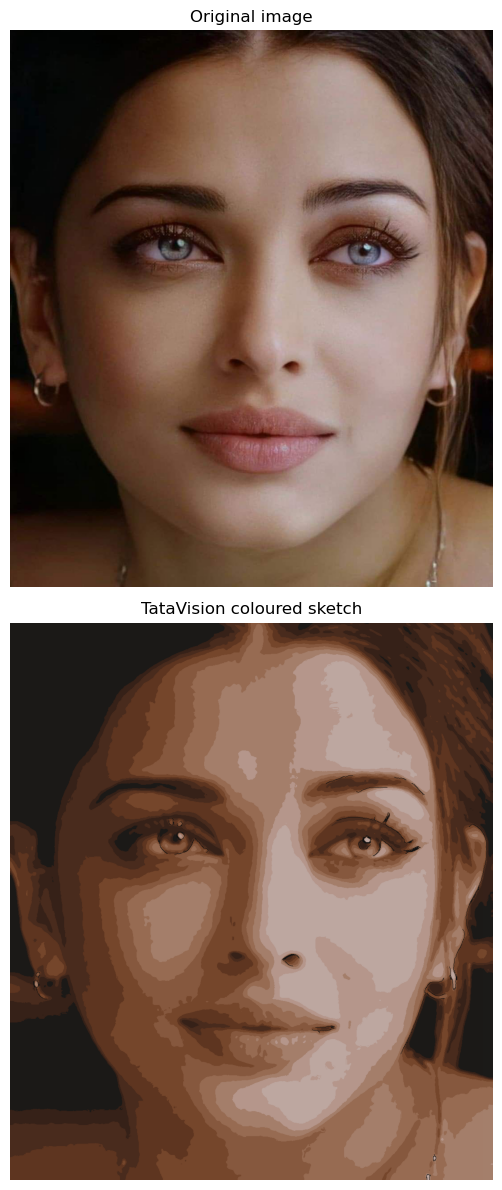

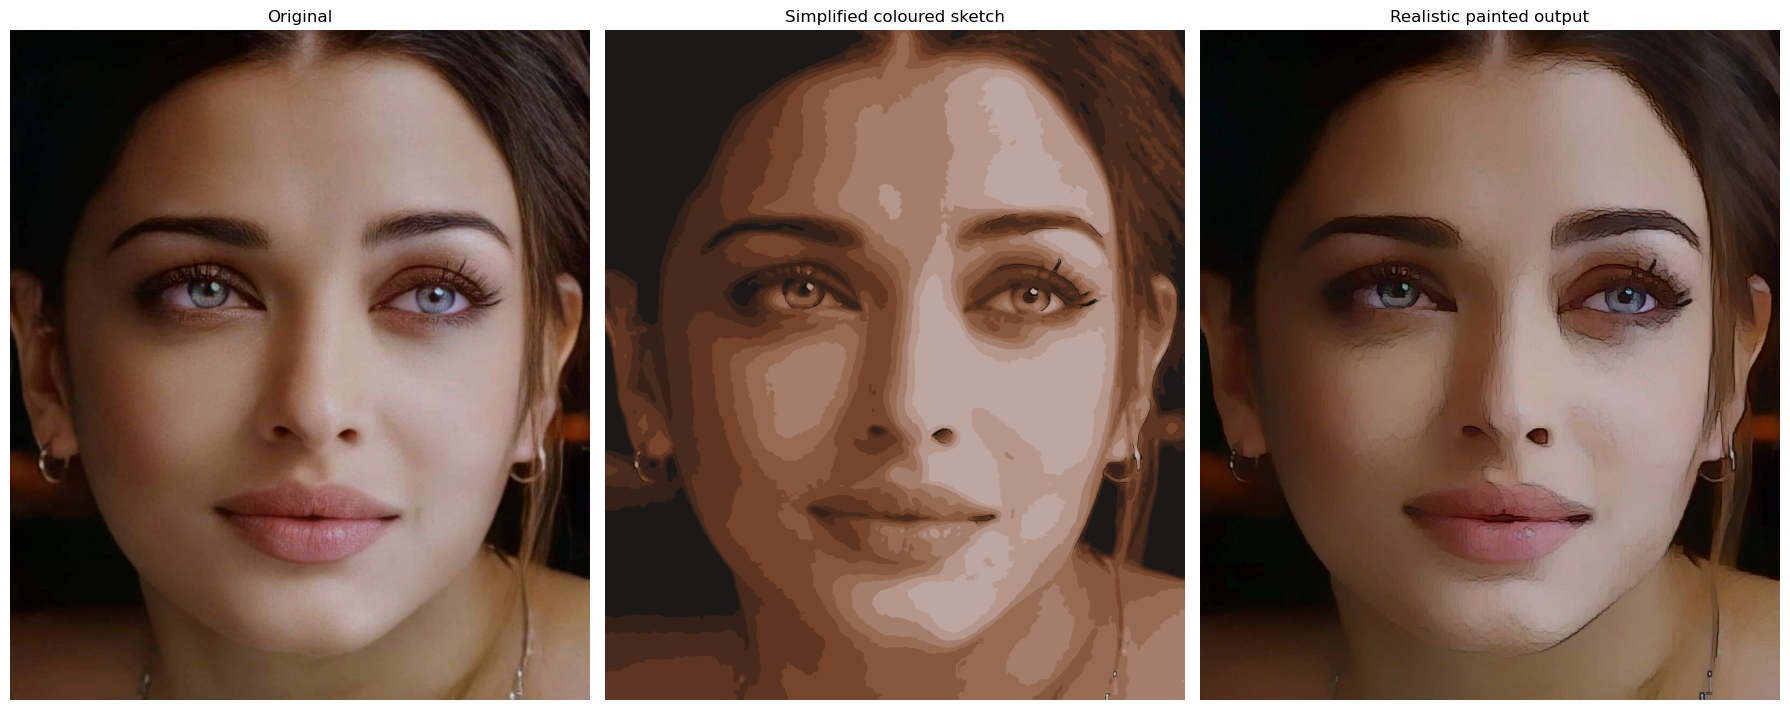

Saved folder: /home/ridhurshan/Desktop/new ai/e/tatavision_xci_coloured_sketch_output
Saved ZIP: /home/ridhurshan/Desktop/new ai/e/tatavision_xci_coloured_sketch_output.zip


In [21]:
OUTPUT_DIR = Path('tatavision_xci_coloured_sketch_output')
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)

Image.fromarray(reference_rgb).save(OUTPUT_DIR / '00_original.png')
Image.fromarray(line_art).save(OUTPUT_DIR / '01_black_white_contour.png')
Image.fromarray(quantized_rgb).save(OUTPUT_DIR / '02_simplified_colours.png')
Image.fromarray(coloured_outline).save(OUTPUT_DIR / '03_coloured_outline.png')
Image.fromarray(final_sketch).save(OUTPUT_DIR / '04_final_coloured_sketch.png')
Image.fromarray(realistic_painted).save(OUTPUT_DIR / '05_realistic_painted_original_colours.png')
for index, stage in enumerate(progressive_stages, start=1):
    Image.fromarray(stage).save(OUTPUT_DIR / f'06_progressive_colour_{index}.png')

# A two-row comparison inspired by Figure 6: source above, generated sketch below.
fig, axes = plt.subplots(2, 1, figsize=(9, 12))
axes[0].imshow(reference_rgb); axes[0].set_title('Original image')
axes[1].imshow(final_sketch); axes[1].set_title('TataVision coloured sketch')
for axis in axes:
    axis.axis('off')
plt.tight_layout()
figure_path = OUTPUT_DIR / '07_figure6_style_comparison.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for axis, image, title in zip(
    axes, [reference_rgb, final_sketch, realistic_painted],
    ['Original', 'Simplified coloured sketch', 'Realistic painted output'],
):
    axis.imshow(image); axis.set_title(title); axis.axis('off')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / '08_all_final_outputs.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

palette_rgb = cv2.cvtColor(centres_lab.reshape(1, -1, 3), cv2.COLOR_LAB2RGB).reshape(-1, 3)
palette = []
for rank, cluster_id in enumerate(cluster_order, start=1):
    colour = palette_rgb[cluster_id].tolist()
    palette.append({
        'rank': rank,
        'rgb': colour,
        'hex': '#{:02X}{:02X}{:02X}'.format(*colour),
        'area_percentage': round(100.0 * cluster_counts[cluster_id] / labels.size, 2),
    })

report = {
    'method': 'XCI-inspired hybrid final renderer',
    'reference_image': str(reference_path),
    'contour_source': curve_source,
    'shading_used': shading_used,
    'parameters': {
        'palette_size': PALETTE_SIZE,
        'gaussian_iterations': GAUSSIAN_ITERATIONS,
        'saturation_factor': SATURATION_FACTOR,
        'paper_whitening': PAPER_WHITENING,
        'line_thickness': LINE_THICKNESS,
        'original_chroma_retention': ORIGINAL_CHROMA_RETENTION,
        'original_detail_blend': ORIGINAL_DETAIL_BLEND,
        'soft_outline_opacity': SOFT_OUTLINE_OPACITY,
        'canvas_grain_strength': CANVAS_GRAIN_STRENGTH,
    },
    'palette': palette,
    'diagnostic_metrics': metrics,
    'warning': 'This renderer approximates the XCI visual style; it is not the paper authors trained GAN.',
}
(OUTPUT_DIR / 'report.json').write_text(json.dumps(report, indent=2), encoding='utf-8')

zip_path = Path('tatavision_xci_coloured_sketch_output.zip')
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as archive:
    for result_file in sorted(OUTPUT_DIR.iterdir()):
        archive.write(result_file, arcname=result_file.name)

print('Saved folder:', OUTPUT_DIR.resolve())
print('Saved ZIP:', zip_path.resolve())
if USE_COLAB_UPLOAD:
    from google.colab import files
    files.download(str(zip_path))


## Correct report/viva description

> The final renderer combines the curve module's contour output, the shading module's luminance guidance and colour information from the original reference. Lab-space quantization creates progressive teaching stages, while edge-aware painterly filtering with original-chroma restoration creates the realistic painted output.

Do not claim this notebook is the paper's trained GAN. It reproduces the visual objective using TataVision's modular outputs, which is more appropriate for the project's step-by-step teaching design.
